In [ ]:
pip install tensorflow matplotlib seaborn scikit-learn

TensorFlow Version: 2.20.0
Running on CPU
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)


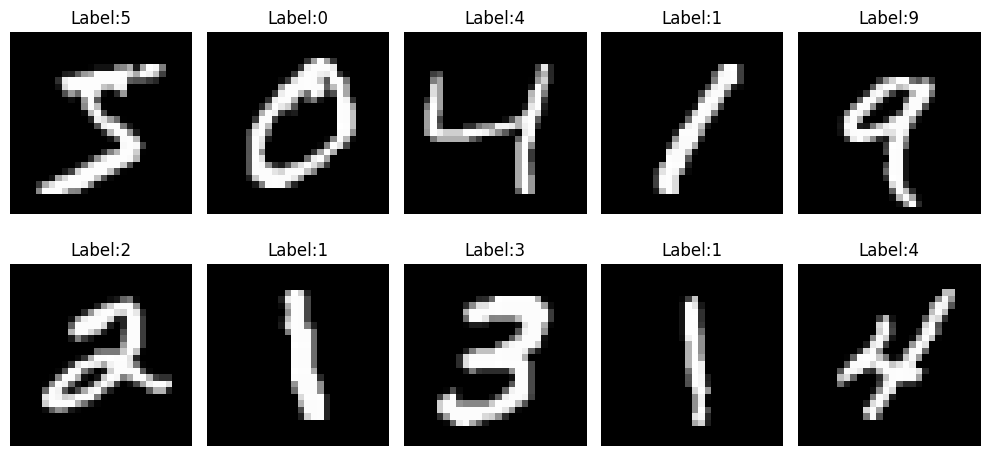

New Shape: (60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.9053 - loss: 0.3101 - val_accuracy: 0.9800 - val_loss: 0.0666 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9696 - loss: 0.1027 - val_accuracy: 0.9862 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9776 - loss: 0.0738 - val_accuracy: 0.9875 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9818 - loss: 0.0605 - val_accuracy: 0.9917 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9848 - loss: 0.0501 - val_accuracy: 0.9903 - val_loss: 0.0333 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9868 - loss: 0.0437 - val_accuracy: 0.9907 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9877 - l


Test Accuracy: 0.9914000034332275


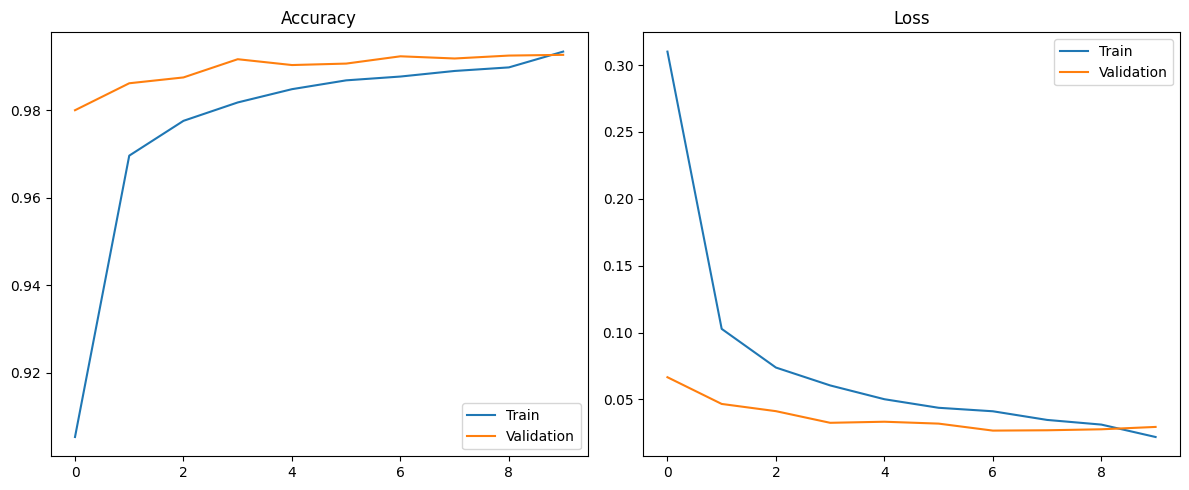

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


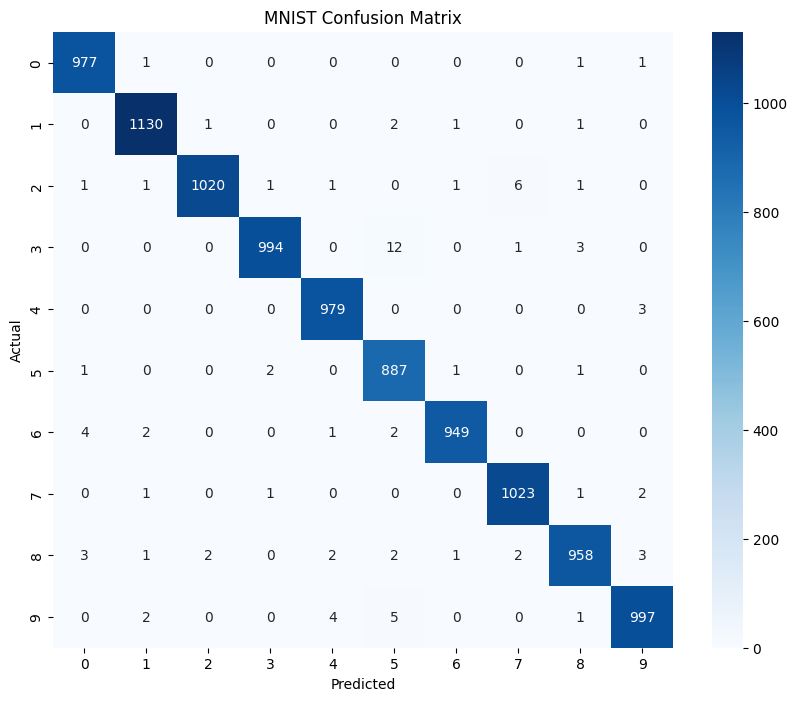

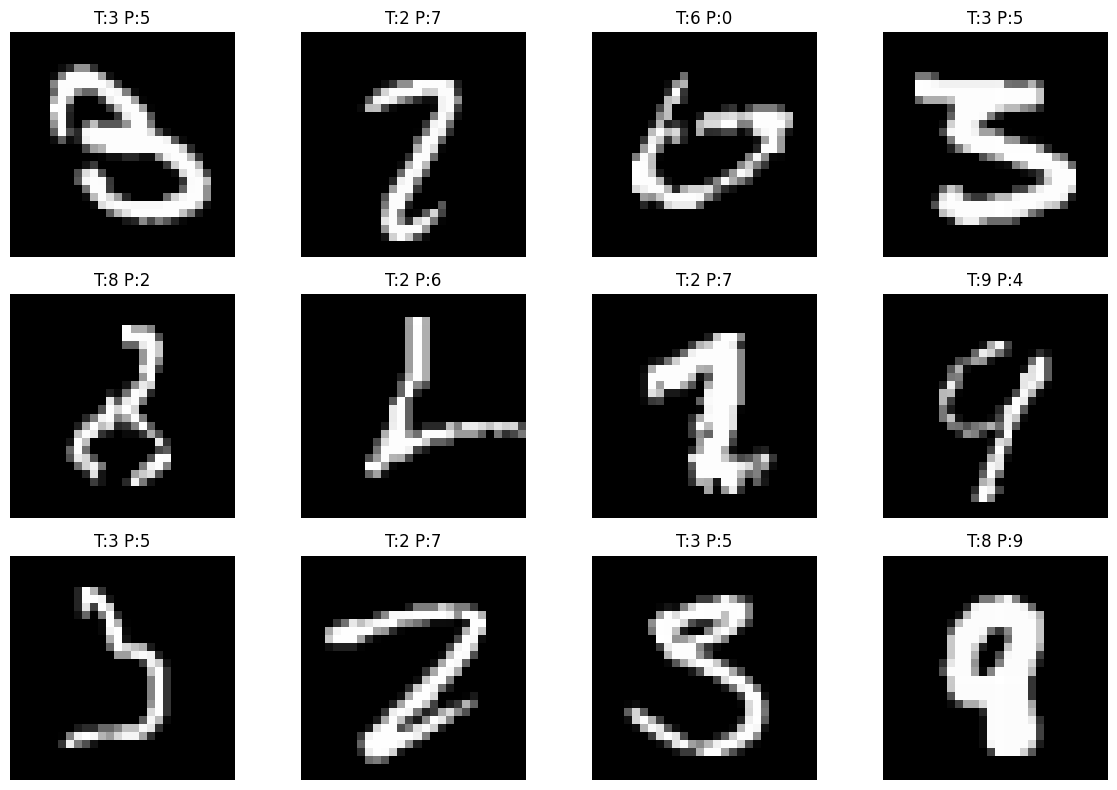

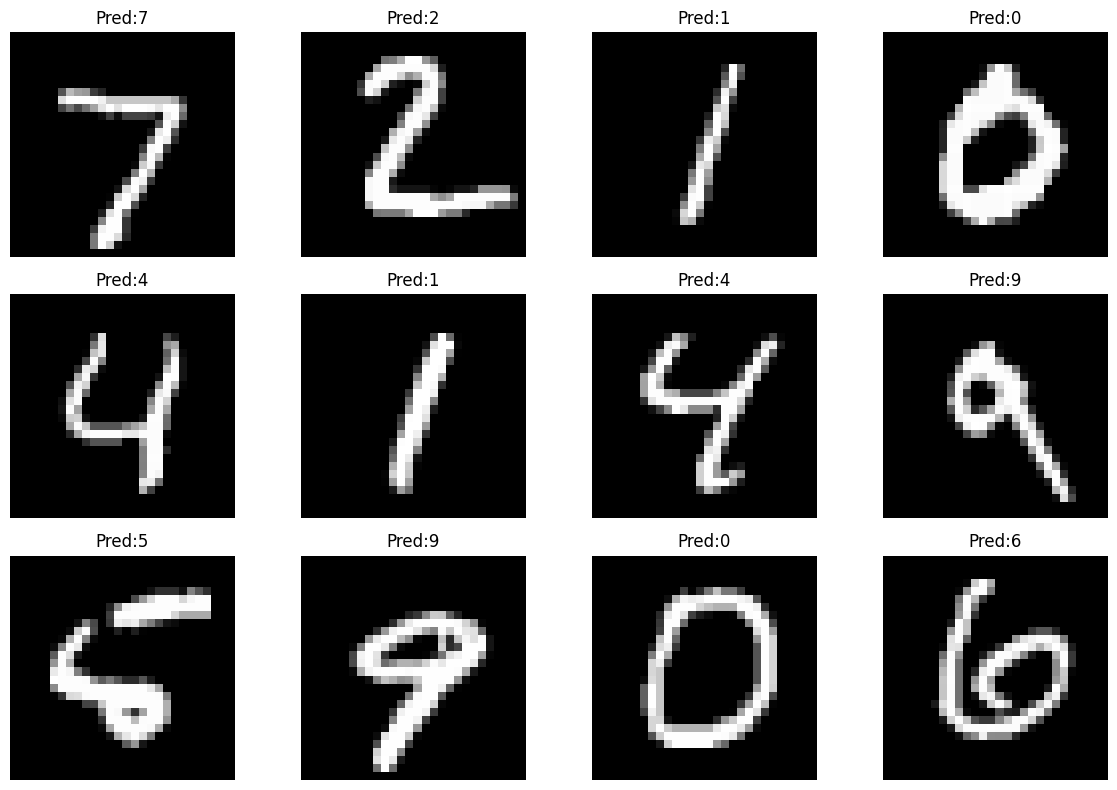


Project Completed Successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix



print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available")
else:
    print("Running on CPU")

# LOAD MNIST

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

# VISUALIZE SAMPLE IMAGES


plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label:{y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("mnist_samples.png")
plt.show()

# PREPROCESSING


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print("New Shape:", x_train.shape)

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)


# CNN MODEL


model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

# SUMMARY


model.summary()


# COMPILE


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# CALLBACKS


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


# TRAIN


history = model.fit(

    x_train,
    y_train_cat,

    validation_split=0.1,

    epochs=20,

    batch_size=128,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)


# EVALUATE


test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("\nTest Accuracy:", test_accuracy)


# SAVE MODEL


model.save("mnist_cnn_model.h5")


# TRAINING CURVES


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Train'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation'
)

plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.title("Loss")
plt.legend()

plt.tight_layout()

plt.savefig("training_history.png")

plt.show()


# PREDICTIONS


predictions = model.predict(x_test)

y_pred = np.argmax(
    predictions,
    axis=1
)


# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "MNIST Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "confusion_matrix.png"
)

plt.show()


# MISCLASSIFIED IMAGES


misclassified = np.where(
    y_pred != y_test
)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(misclassified[:12]):

    plt.subplot(3,4,i+1)

    plt.imshow(
        x_test[idx].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"T:{y_test[idx]} P:{y_pred[idx]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    "misclassified_examples.png"
)

plt.show()

# SAMPLE PREDICTIONS


plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        x_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Pred:{y_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    "sample_predictions.png"
)

plt.show()

print("\nProject Completed Successfully!")